In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [5]:
df=pd.read_csv("files/co2.csv")
df.head()


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [6]:
df.shape

(7385, 12)

In [7]:
df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [10]:
df.isnull().sum()

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

In [15]:
numeric_df=df.select_dtypes(include=['int64','float64'])
numeric_columns=numeric_df.columns
print(numeric_columns)

Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')


In [49]:
corr_matrix=numeric_df.corr()
targets=['CO2 Emissions(g/km)']
corr_matrix[targets]

,CO2 Emissions(g/km)
Engine Size(L),0.851145
Cylinders,0.832644
Fuel Consumption City (L/100 km),0.919592
Fuel Consumption Hwy (L/100 km),0.883536
Fuel Consumption Comb (L/100 km),0.918052
Fuel Consumption Comb (mpg),-0.907426
CO2 Emissions(g/km),1.000000


In [50]:
exclude_features=['Fuel Consumption City (L/100 km)','Fuel Consumption Hwy (L/100 km)','Fuel Consumption Comb (mpg)']

In [52]:
for target in targets:
    final_features = [
        col for col in numeric_columns
        if col not in exclude_features and col != target]
    print(f"Target: {target}")
    print(final_features)

Target: CO2 Emissions(g/km)
['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']


In [57]:
#Correlation matrix of final features 
final_corr_matrix=df[final_features+targets].corr()
print(final_corr_matrix)

                                  Engine Size(L)  Cylinders  \
Engine Size(L)                          1.000000   0.927653   
Cylinders                               0.927653   1.000000   
Fuel Consumption Comb (L/100 km)        0.817060   0.780534   
CO2 Emissions(g/km)                     0.851145   0.832644   

                                  Fuel Consumption Comb (L/100 km)  \
Engine Size(L)                                            0.817060   
Cylinders                                                 0.780534   
Fuel Consumption Comb (L/100 km)                          1.000000   
CO2 Emissions(g/km)                                       0.918052   

                                  CO2 Emissions(g/km)  
Engine Size(L)                               0.851145  
Cylinders                                    0.832644  
Fuel Consumption Comb (L/100 km)             0.918052  
CO2 Emissions(g/km)                          1.000000  


<Axes: >

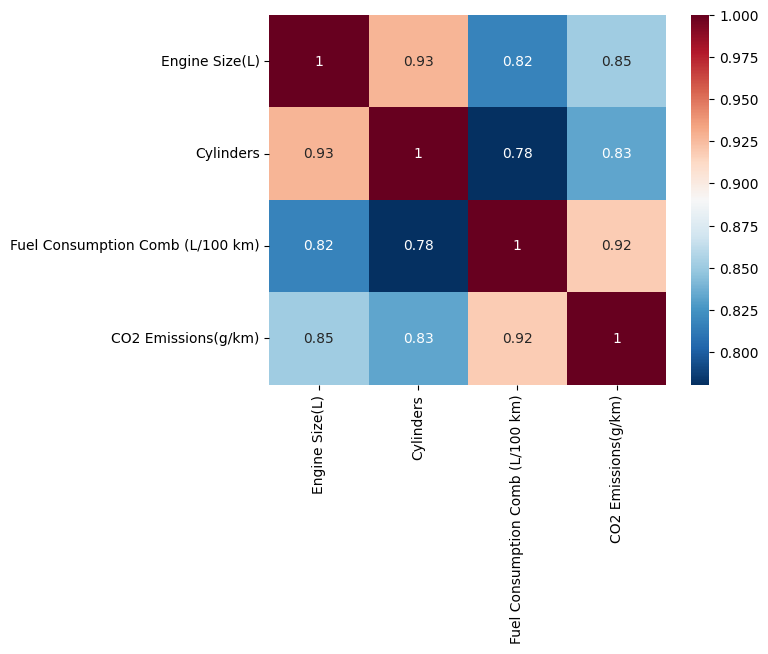

In [60]:
sns.heatmap(final_corr_matrix,annot=True,cmap="RdBu_r")


In [70]:
#to check for feature scaling:
df[final_features+targets].describe()
#we need to scale them



,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,10.975071,250.584699
std,1.354170,1.828307,2.892506,58.512679
min,0.900000,3.000000,4.100000,96.000000
25%,2.000000,4.000000,8.900000,208.000000
50%,3.000000,6.000000,10.600000,246.000000
75%,3.700000,6.000000,12.600000,288.000000
max,8.400000,16.000000,26.100000,522.000000


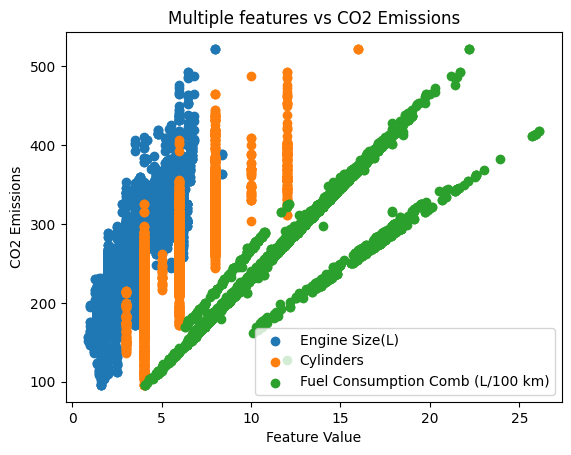

In [69]:

features = ['Engine Size', 'Cylinders', 'Fuel Consumption Comb']
target = 'CO2 Emissions(g/km)'


for feature in final_features:
    plt.scatter(df[feature], df[target], label=feature)

plt.xlabel('Feature Value')
plt.ylabel('CO2 Emissions')
plt.title('Multiple features vs CO2 Emissions')
plt.legend()
plt.show()


In [ ]:
#There ar eoutliers, so we choose robust scaling 

In [72]:
#Robust scaling: 
scale_df=df[final_features].copy()
for col in scale_df.columns:
    median=scale_df[col].median()
    Q1=scale_df[col].quantile(0.25)
    Q3=scale_df[col].quantile(0.75)
    IQR=Q3-Q1

    scale_df[col]=(scale_df[col]-median)/IQR

In [73]:
#assign y and x values
x=scale_df.values
y=df[target].values

In [75]:
#split into train and test set:
# (70% train, 30% test)
np.random.seed(42)
indices = np.arange(len(x))
np.random.shuffle(indices)

split = int(0.7 * len(x))
train_idx = indices[:split]
test_idx = indices[split:]

X_train = x[train_idx]
X_test = x[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

In [76]:
#Linear-regression model
class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, iterations=2000):
        self.lr = learning_rate
        self.iterations = iterations
        self.costs = []

    def fit(self, x, y):
        #Initialize paramters:
        self.m, self.n = x.shape
        self.w = np.zeros(self.n)
        self.b = 0

        for i in range(self.iterations):
            y_pred = self.predict(x)

            dw = (2/self.m) * x.T.dot(y_pred - y) #Changing the weight, partial derivative of j wrt w
            db = (2/self.m) * np.sum(y_pred - y) #partial derivative of J wrt b

            self.w -= self.lr * dw 
            self.b -= self.lr * db

            cost = np.mean((y - y_pred) ** 2)
            self.costs.append(cost)

    def predict(self, x):
        return x.dot(self.w) + self.b


In [77]:
model = LinearRegressionGD(learning_rate=0.01, iterations=2000)
model.fit(X_train, y_train)

print("Weights:", model.w)
print("Bias:", model.b)


Weights: [15.30609668  9.013142   47.02844688]
Bias: 245.89431718207814


In [78]:
y_pred = model.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
ss_res = np.sum((y_test - y_pred) ** 2)
r2 = 1 - ss_res / ss_total

print("\nRMSE:", rmse)
print("R-squared:", r2)


RMSE: 19.821533826368274
R-squared: 0.8898929622394058


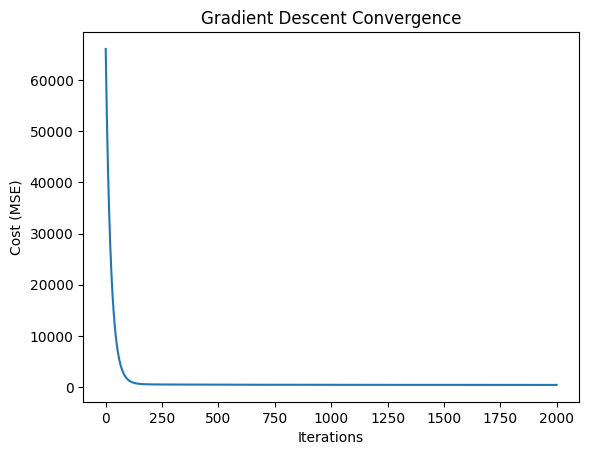

In [79]:
plt.plot(model.costs)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()


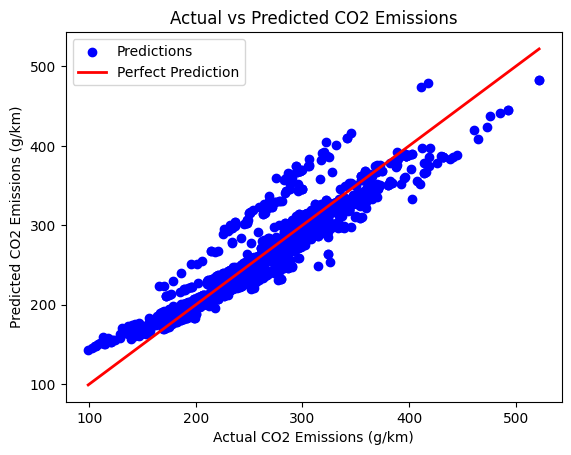

In [83]:

# Scatter plot of actual vs predicted
plt.scatter(y_test, y_pred, color='blue', label='Predictions')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='red', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual CO2 Emissions (g/km)")
plt.ylabel("Predicted CO2 Emissions (g/km)")
plt.title("Actual vs Predicted CO2 Emissions")
plt.legend()